In [110]:
!pip install scikit-learn

In [2]:
import pandas as pd


In [3]:
df = pd.read_csv('billings.csv')
df.head()


C:\Users\Rishi\AppData\Local\Temp\ipykernel_5256\3693011849.py:1: DtypeWarning: Columns (15,16,19,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('billings.csv')


,Co_Ref,Renewal_Month,Connection_Net,Connection_Qty,Discount_Amount,Sustainability_Score,Total_Renewal_Score_New,Starting_Connection_Net,Starting_Connection_Qty,Last_Years_Price,...,Connection_Group,Tenure_Group,#_of_Connection,Last_Renewal,Last_Band,Last_Total_Net_Paid,Last_Connections,Anchor_Group,Renewal_Year,DateTime_Out
0,VT6174,01-11-2024,NaN,NaN,NaN,8.0,42.5,NaN,NaN,799.0,...,1,3,1.0,01-11-2023,Band B,664.0,1.0,1,2024,01-11-2024
1,VD3828,01-08-2025,NaN,NaN,NaN,8.0,41.5,NaN,NaN,799.0,...,1,1,1.0,NaN,NaN,NaN,NaN,1,2025,01-08-2025
2,DV8120,01-03-2025,NaN,NaN,NaN,8.0,33.0,NaN,NaN,799.0,...,1,4+,1.0,01-03-2024,Band C1,749.0,1.0,1,2025,01-03-2025
3,EZ9894,01-06-2025,NaN,NaN,NaN,9.5,44.5,NaN,NaN,799.0,...,1,4+,1.0,01-06-2024,Band C1,749.0,1.0,1,2025,01-06-2025
4,FA8957,01-03-2025,NaN,NaN,NaN,9.5,42.5,NaN,NaN,799.0,...,1,3,1.0,01-03-2024,Band C1,749.0,1.0,1,2025,01-03-2025


In [4]:
selected_columns = []

In [5]:
date_col = ['Renewal_Month', 'Proforma_Date','Registration_Date','Prospect_Renewal_Date','Closed_Date','Last_Renewal','DateTime_Out']
df_dates = df[date_col].copy()
df_dates

,Renewal_Month,Proforma_Date,Registration_Date,Prospect_Renewal_Date,Closed_Date,Last_Renewal,DateTime_Out
0,01-11-2024,06-09-2024,05-11-2021,05-11-2024,05-11-2024,01-11-2023,01-11-2024
1,01-08-2025,05-06-2025,09-08-2024,09-08-2025,09-08-2025,NaN,01-08-2025
2,01-03-2025,10-01-2025,12-03-2015,12-03-2025,12-03-2025,01-03-2024,01-03-2025
3,01-06-2025,16-04-2025,27-06-2014,29-06-2025,29-06-2025,01-06-2024,01-06-2025
4,01-03-2025,08-01-2025,25-03-2022,25-03-2025,25-03-2025,01-03-2024,01-03-2025
...,...,...,...,...,...,...,...
122077,01-04-2023,06-02-2023,25-04-2020,25-04-2023,13-06-2023,NaN,01-04-2023
122078,01-06-2023,11-04-2023,24-06-2020,24-06-2023,31-05-2023,NaN,01-06-2023
122079,01-09-2023,06-07-2023,15-09-2020,15-09-2023,11-09-2023,NaN,01-09-2023
122080,01-08-2023,07-06-2023,03-08-2020,03-08-2023,20-09-2023,NaN,01-08-2023


In [6]:
df_dates.isnull().sum()

Renewal_Month                0
Proforma_Date              304
Registration_Date         1018
Prospect_Renewal_Date        0
Closed_Date               8188
Last_Renewal             48291
DateTime_Out                 0
dtype: int64

In [7]:
df['Prospect_Outcome'].value_counts()

Prospect_Outcome
Won        101226
Churned     12668
Open         8188
Name: count, dtype: int64

In [8]:
renewal_dateout_count = (df['Renewal_Month'] != df['DateTime_Out']).sum()
print(renewal_dateout_count)

0


In [9]:
df_dates['Prospect_Outcome'] = df['Prospect_Outcome']
df_dates

,Renewal_Month,Proforma_Date,Registration_Date,Prospect_Renewal_Date,Closed_Date,Last_Renewal,DateTime_Out,Prospect_Outcome
0,01-11-2024,06-09-2024,05-11-2021,05-11-2024,05-11-2024,01-11-2023,01-11-2024,Won
1,01-08-2025,05-06-2025,09-08-2024,09-08-2025,09-08-2025,NaN,01-08-2025,Won
2,01-03-2025,10-01-2025,12-03-2015,12-03-2025,12-03-2025,01-03-2024,01-03-2025,Won
3,01-06-2025,16-04-2025,27-06-2014,29-06-2025,29-06-2025,01-06-2024,01-06-2025,Won
4,01-03-2025,08-01-2025,25-03-2022,25-03-2025,25-03-2025,01-03-2024,01-03-2025,Won
...,...,...,...,...,...,...,...,...
122077,01-04-2023,06-02-2023,25-04-2020,25-04-2023,13-06-2023,NaN,01-04-2023,Won
122078,01-06-2023,11-04-2023,24-06-2020,24-06-2023,31-05-2023,NaN,01-06-2023,Won
122079,01-09-2023,06-07-2023,15-09-2020,15-09-2023,11-09-2023,NaN,01-09-2023,Won
122080,01-08-2023,07-06-2023,03-08-2020,03-08-2023,20-09-2023,NaN,01-08-2023,Won


In [10]:
selected_columns.extend([])

In [11]:
df_dates[df_dates['Prospect_Outcome'] == 'Won']


,Renewal_Month,Proforma_Date,Registration_Date,Prospect_Renewal_Date,Closed_Date,Last_Renewal,DateTime_Out,Prospect_Outcome
0,01-11-2024,06-09-2024,05-11-2021,05-11-2024,05-11-2024,01-11-2023,01-11-2024,Won
1,01-08-2025,05-06-2025,09-08-2024,09-08-2025,09-08-2025,NaN,01-08-2025,Won
2,01-03-2025,10-01-2025,12-03-2015,12-03-2025,12-03-2025,01-03-2024,01-03-2025,Won
3,01-06-2025,16-04-2025,27-06-2014,29-06-2025,29-06-2025,01-06-2024,01-06-2025,Won
4,01-03-2025,08-01-2025,25-03-2022,25-03-2025,25-03-2025,01-03-2024,01-03-2025,Won
...,...,...,...,...,...,...,...,...
122077,01-04-2023,06-02-2023,25-04-2020,25-04-2023,13-06-2023,NaN,01-04-2023,Won
122078,01-06-2023,11-04-2023,24-06-2020,24-06-2023,31-05-2023,NaN,01-06-2023,Won
122079,01-09-2023,06-07-2023,15-09-2020,15-09-2023,11-09-2023,NaN,01-09-2023,Won
122080,01-08-2023,07-06-2023,03-08-2020,03-08-2023,20-09-2023,NaN,01-08-2023,Won


In [12]:
df_dates[df_dates['Prospect_Outcome'] == 'Churned']

,Renewal_Month,Proforma_Date,Registration_Date,Prospect_Renewal_Date,Closed_Date,Last_Renewal,DateTime_Out,Prospect_Outcome
28953,01-11-2024,05-09-2024,03-11-2021,03-11-2024,20-05-2025,01-11-2023,01-11-2024,Churned
28954,01-02-2025,06-12-2024,07-02-2022,07-02-2025,17-02-2025,01-02-2024,01-02-2025,Churned
28955,01-03-2025,08-01-2025,26-03-2024,26-03-2025,29-04-2025,NaN,01-03-2025,Churned
28956,01-12-2024,10-10-2024,12-12-2017,12-12-2024,11-03-2025,01-12-2023,01-12-2024,Churned
28957,01-07-2025,12-05-2025,23-07-2020,23-07-2025,04-11-2025,01-07-2024,01-07-2025,Churned
...,...,...,...,...,...,...,...,...
86977,01-10-2023,11-08-2023,27-10-2017,27-10-2023,19-01-2024,NaN,01-10-2023,Churned
86979,01-08-2023,09-06-2023,08-03-2017,22-08-2023,27-09-2023,NaN,01-08-2023,Churned
86980,01-12-2023,11-10-2023,06-12-2011,06-12-2023,19-12-2023,NaN,01-12-2023,Churned
86981,01-11-2023,13-09-2023,23-11-2016,23-11-2023,06-02-2024,NaN,01-11-2023,Churned


In [13]:
df_dates['Co_Ref'] = df['Co_Ref']

In [ ]:
df_dates[df_dates['Co_Ref']=='YG4840'].sort_values(by='Renewal_Month')

,Renewal_Month,Proforma_Date,Registration_Date,Prospect_Renewal_Date,Closed_Date,Last_Renewal,DateTime_Out,Prospect_Outcome,Co_Ref
116122,01-02-2023,12-12-2022,20-02-2017,20-02-2023,26-04-2023,NaN,01-02-2023,Won,YG4840
51796,01-02-2024,11-12-2023,20-02-2017,20-02-2024,26-02-2024,01-02-2023,01-02-2024,Won,YG4840
49724,01-02-2025,09-12-2024,20-02-2017,20-02-2025,20-02-2025,01-02-2024,01-02-2025,Won,YG4840
52269,01-02-2026,08-12-2025,20-02-2017,20-02-2026,17-02-2026,01-02-2025,01-02-2026,Won,YG4840
59026,01-02-2027,NaN,20-02-2017,20-02-2027,17-02-2026,01-02-2026,01-02-2027,Won,YG4840


In [ ]:
df[df['Prospect_Outcome']=='Churned']['Co_Ref'].value_counts()

Co_Ref
JP2039    2
RP5922    2
ZF2530    2
MI8796    2
CP6018    2
         ..
BS9790    1
CD5280    1
NK1200    1
NK4412    1
NL4830    1
Name: count, Length: 12588, dtype: int64

In [ ]:
df_dates[df_dates['Co_Ref']=='JP2039'].sort_values(by='Renewal_Month')

,Renewal_Month,Proforma_Date,Registration_Date,Prospect_Renewal_Date,Closed_Date,Last_Renewal,DateTime_Out,Prospect_Outcome,Co_Ref
115811,01-01-2023,07-11-2022,24-04-2025,04-01-2023,09-01-2023,NaN,01-01-2023,Won,JP2039
58543,01-01-2024,07-11-2023,24-04-2025,04-01-2024,15-11-2023,01-01-2023,01-01-2024,Won,JP2039
31933,01-01-2025,07-11-2024,24-04-2025,04-01-2025,15-01-2025,01-01-2024,01-01-2025,Churned,JP2039
31156,01-04-2026,11-02-2026,24-04-2025,24-04-2026,26-02-2026,NaN,01-04-2026,Churned,JP2039


In [15]:
selected_columns.extend(['Prospect_Renewal_Date','Closed_Date','Proforma_Date','Last_Renewal'])

In [24]:
score_col = ['Sustainability_Score','Total_Renewal_Score_New','Auto_Renewal_Score','Status_Scores','Anchoring_Score','Tenure_Scores','Renewal_Score_At_Release']
df_scores = df[score_col].copy()

In [19]:

df_scores['Prospect_Outcome']=df['Prospect_Outcome']
df_scores.head()

,Sustainability_Score,Total_Renewal_Score_New,Auto_Renewal_Score,Status_Scores,Anchoring_Score,Tenure_Scores,Renewal_Score_At_Release,Prospect_Outcome
0,8.0,42.5,9,9,7.5,9.0,26.0,Won
1,8.0,41.5,9,9,7.5,8.0,24.5,Won
2,8.0,33.0,8,0,7.5,9.5,24.0,Won
3,9.5,44.5,9,9,7.5,9.5,27.0,Won
4,9.5,42.5,9,8,7.5,8.5,26.0,Won


In [21]:
df_scores.dtypes

Sustainability_Score        float64
Total_Renewal_Score_New     float64
Auto_Renewal_Score            int64
Status_Scores                 int64
Anchoring_Score             float64
Tenure_Scores               float64
Renewal_Score_At_Release    float64
Prospect_Outcome             object
dtype: object

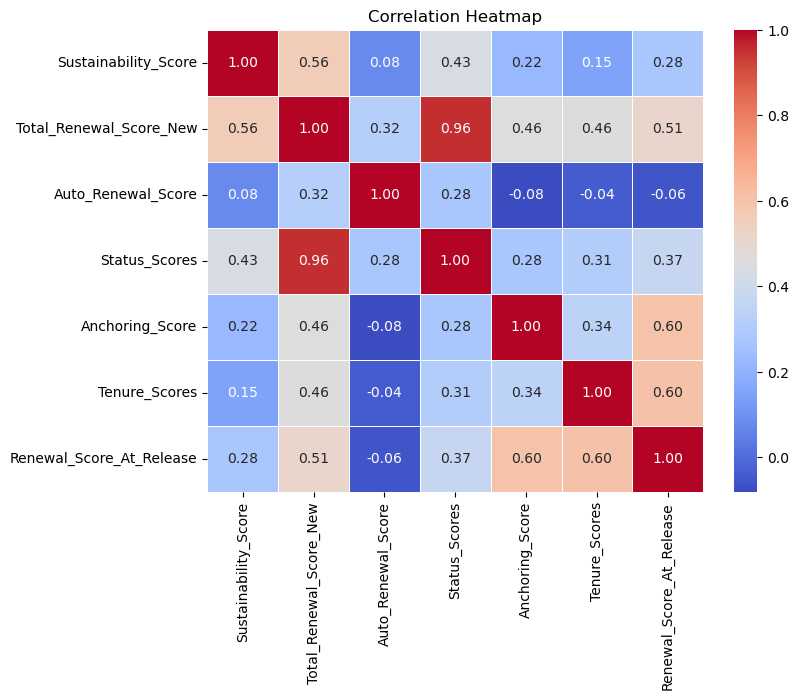

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix = df_scores.corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [26]:
selected_columns.extend(score_col)

In [31]:
rate_col = ['Connection_Net','Connection_Qty','Starting_Connection_Net','Starting_Connection_Qty','Starting_Net','Starting_Vat','Starting_Gross','Starting_Membership_Net','Starting_Package_Net','Starting_PQQ_Net','Gross','Membership_Net','Package_Net','PQQNet','Total_Net_Paid','Amount','Total_Amount','Last_Total_Net_Paid']
df_rate = df[rate_col].copy()

In [32]:
df_rate.dtypes

Connection_Net             float64
Connection_Qty             float64
Starting_Connection_Net    float64
Starting_Connection_Qty    float64
Starting_Net                 int64
Starting_Vat               float64
Starting_Gross             float64
Starting_Membership_Net      int64
Starting_Package_Net         int64
Starting_PQQ_Net             int64
Gross                      float64
Membership_Net             float64
Package_Net                float64
PQQNet                       int64
Total_Net_Paid             float64
Amount                       int64
Total_Amount               float64
Last_Total_Net_Paid        float64
dtype: object

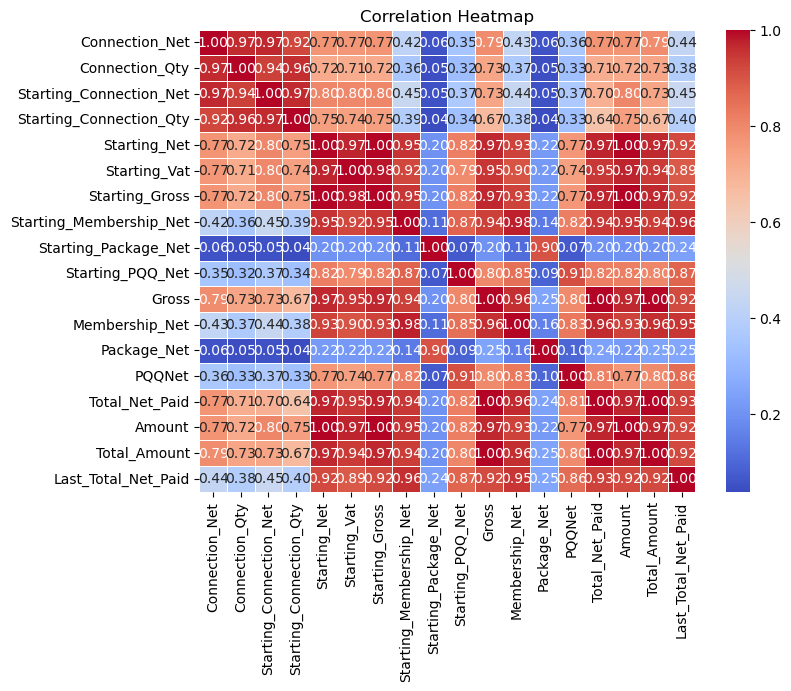

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

rate_matrix = df_rate.corr()

plt.figure(figsize=(8,6))
sns.heatmap(rate_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [34]:
df_rate.isnull().sum()

Connection_Net             114045
Connection_Qty             114045
Starting_Connection_Net    113537
Starting_Connection_Qty    113537
Starting_Net                    0
Starting_Vat                    0
Starting_Gross                  0
Starting_Membership_Net         0
Starting_Package_Net            0
Starting_PQQ_Net                0
Gross                           0
Membership_Net                  0
Package_Net                     0
PQQNet                          0
Total_Net_Paid              20856
Amount                          0
Total_Amount                    0
Last_Total_Net_Paid         48356
dtype: int64

In [35]:
calculate_col = ['Amount','Starting_Vat','Starting_Gross']
df_call = df[calculate_col].copy()

In [39]:
df_call['Amount_multiplied_by_0_2'] = df_call['Amount'] * 0.2
df_call['Amount_multiplied_by_1_2'] = df_call['Amount'] * 1.2

df_call.head(20)

,Amount,Starting_Vat,Starting_Gross,Amount_multiplied_by_0_2,Amount_multiplied_by_1_2
0,919,183.8,1102.8,183.8,1102.8
1,919,183.8,1102.8,183.8,1102.8
2,799,159.8,958.8,159.8,958.8
3,799,159.8,958.8,159.8,958.8
4,799,159.8,958.8,159.8,958.8
5,799,159.8,958.8,159.8,958.8
6,799,159.8,958.8,159.8,958.8
7,799,159.8,958.8,159.8,958.8
8,799,159.8,958.8,159.8,958.8
9,799,159.8,958.8,159.8,958.8


In [40]:
selected_columns.extend(['Membership_Net','Package_Net','PQQNet','Amount','Total_Amount'])

In [43]:
print(selected_columns)

['Prospect_Renewal_Date', 'Closed_Date', 'Proforma_Date', 'Last_Renewal', 'Sustainability_Score', 'Total_Renewal_Score_New', 'Auto_Renewal_Score', 'Status_Scores', 'Anchoring_Score', 'Tenure_Scores', 'Renewal_Score_At_Release', 'Membership_Net', 'Package_Net', 'PQQNet', 'Amount', 'Total_Amount']


In [42]:
print(len((selected_columns)))

16


In [90]:
final_cols = ['Co_Ref','Sustainability_Score','Total_Renewal_Score_New','Auto_Renewal_Score','Status_Scores','Anchoring_Score','Tenure_Scores','Renewal_Score_At_Release','Proforma_Account_Stage','Proforma_Audit_Status','Current_Auto_Renewal_Flag','Current_World_Pay_Token','Proforma_Membership_Status','Prospect_Status','Band','#_of_Connection','Membership_Net','Package_Net','PQQNet','Amount','Total_Amount','Last_Years_Price','Proforma_Date','Prospect_Renewal_Date','Closed_Date','Last_Renewal','Tenure_Years','Prospect_Outcome']
df_main = df[final_cols].copy()

In [91]:
df_main = df_main[df_main['Prospect_Outcome'] != 'Open']

In [92]:
df_main.count()

Co_Ref                        113894
Sustainability_Score          113894
Total_Renewal_Score_New       113894
Auto_Renewal_Score            113894
Status_Scores                 113894
Anchoring_Score               113894
Tenure_Scores                 113894
Renewal_Score_At_Release      113772
Proforma_Account_Stage        104669
Proforma_Audit_Status         104669
Current_Auto_Renewal_Flag     113894
Current_World_Pay_Token       113894
Proforma_Membership_Status    113772
Prospect_Status               113894
Band                          113874
#_of_Connection               113772
Membership_Net                113894
Package_Net                   113894
PQQNet                        113894
Amount                        113894
Total_Amount                  113894
Last_Years_Price              105077
Proforma_Date                 113595
Prospect_Renewal_Date         113894
Closed_Date                   113894
Last_Renewal                   67210
Tenure_Years                  112919
P

In [50]:
df_main.to_csv('billings_selected.csv', index=False)

In [56]:
ref = ['Co_Ref','Prospect_Outcome','Prospect_Renewal_Date']
df_ref = df[ref].copy()

In [57]:
df_ref = df_ref[df_ref['Prospect_Outcome'] != 'Open']

In [58]:
df_ref.count()

Co_Ref                   113894
Prospect_Outcome         113894
Prospect_Renewal_Date    113894
dtype: int64

In [59]:
df_ref.to_csv('match.csv', index=False)

In [61]:
df_ref.dtypes

Co_Ref                   object
Prospect_Outcome         object
Prospect_Renewal_Date    object
dtype: object

In [60]:
display(df_ref['Co_Ref'].drop_duplicates().count())

np.int64(46339)

In [89]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113894 entries, 0 to 122081
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Co_Ref                      113894 non-null  object 
 1   Sustainability_Score        113894 non-null  float64
 2   Total_Renewal_Score_New     113894 non-null  float64
 3   Auto_Renewal_Score          113894 non-null  int64  
 4   Status_Scores               113894 non-null  int64  
 5   Anchoring_Score             113894 non-null  float64
 6   Tenure_Scores               113894 non-null  float64
 7   Renewal_Score_At_Release    113894 non-null  float64
 8   Proforma_Audit_Status       104669 non-null  object 
 9   Current_Auto_Renewal_Flag   113894 non-null  object 
 10  Current_World_Pay_Token     113894 non-null  object 
 11  Proforma_Membership_Status  113772 non-null  object 
 12  Prospect_Status             113894 non-null  object 
 13  Band               

In [93]:
df_main.loc[:, 'Renewal_Score_At_Release'] = df_main['Renewal_Score_At_Release'].median()

In [94]:
df_main.loc[:, 'Proforma_Account_Stage'] = df_main['Proforma_Account_Stage'].fillna('Unknown')

In [95]:
df_main = df_main.drop(columns=['Proforma_Audit_Status'])

In [97]:
df_main.loc[:, 'Proforma_Membership_Status'] = df_main['Proforma_Membership_Status'].fillna('Unknown')

In [103]:
df_main.loc[:, 'Band'] = df_main['Band'].fillna('Unknown')

In [105]:
df_main.loc[:, 'Proforma_Date'] = df_main['Proforma_Date'].fillna('Unknown')

In [107]:
df_main.loc[:, 'Last_Renewal'] = df_main['Last_Renewal'].fillna('Unknown')

In [99]:
df_main.loc[:, '#_of_Connection'] = df_main['#_of_Connection'].median()

In [101]:
df_main.loc[:, 'Last_Years_Price'] = df_main['Last_Years_Price'].median()

In [108]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113894 entries, 0 to 122081
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Co_Ref                      113894 non-null  object 
 1   Sustainability_Score        113894 non-null  float64
 2   Total_Renewal_Score_New     113894 non-null  float64
 3   Auto_Renewal_Score          113894 non-null  int64  
 4   Status_Scores               113894 non-null  int64  
 5   Anchoring_Score             113894 non-null  float64
 6   Tenure_Scores               113894 non-null  float64
 7   Renewal_Score_At_Release    113894 non-null  float64
 8   Proforma_Account_Stage      113894 non-null  object 
 9   Current_Auto_Renewal_Flag   113894 non-null  object 
 10  Current_World_Pay_Token     113894 non-null  object 
 11  Proforma_Membership_Status  113894 non-null  object 
 12  Prospect_Status             113894 non-null  object 
 13  Band               

In [109]:
df_main.to_csv('billings_cleaned.csv', index=False)